In [ ]:
from ecg_core.rr_hr_hrv import *
import matplotlib.pyplot as plt
from matplotlib import ticker

ecg = pd.read_csv('ecg_log_2026-02-21_233840.csv')

## 1. 随机选一段画图看看

window: 1771717245.7066426 → 1771717265.7066426
4980


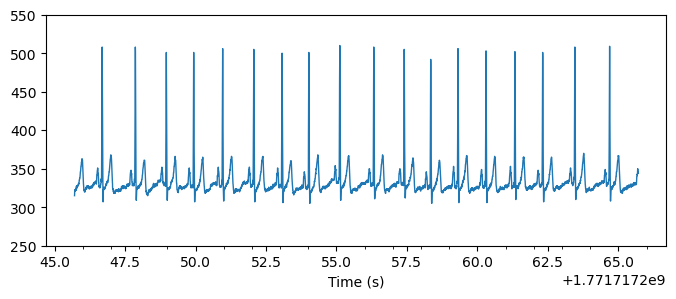

In [2]:
sub_df, t0, t1 = random_time_slice(ecg, s=20)
print("window:", t0, "→", t1)
print(len(sub_df))

fig = plt.figure(figsize=(8, 3))
ax = plt.gca()
ax.plot(sub_df.time, sub_df.ecg, linewidth=1)
ax.set_xlabel('Time (s)')
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.set_ylim(250, 550)
plt.savefig('ecg_10s.jpg', dpi=300, bbox_inches='tight')

## 2. R 峰识别

2026-02-22 05:37:57 – 2026-02-22 05:38:27  |  00:00:29
Samples: 7470  |  fs: 250.00 Hz  |  Beats: 29
Mean HR: 56 bpm  |  SDNN: 66 ms  |  RMSSD: 85 ms


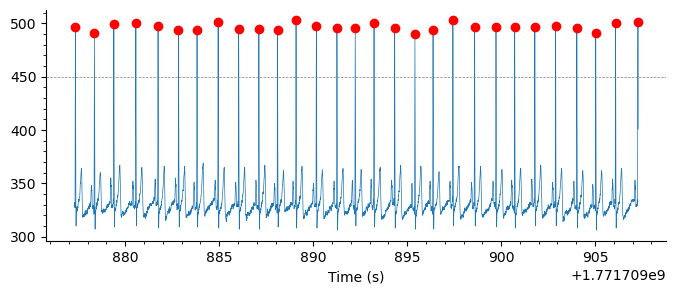

In [3]:
sub_df, t0, t1 = random_time_slice(ecg, s=30)
beats = BeatCalc(sub_df)
print(beats.ecg_info())

fig = plt.figure(figsize=(8, 3))
ax = plt.gca()
ax.plot(sub_df.time, sub_df.ecg, linewidth=0.5, zorder=-1)
ax.set_xlabel('Time (s)')
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

beat_idxs = beats.peaks + sub_df.index[0]
ax.scatter(
    sub_df.loc[beat_idxs, 'time'], 
    sub_df.loc[beat_idxs, 'ecg'], 
    color='red', zorder=1
    )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(450, color='gray', linewidth=0.5, linestyle='--')


In [4]:
def get_dtime_nospace(timestamp):
    dt_object = datetime.datetime.fromtimestamp(timestamp)
    formatted_time = dt_object.strftime('%Y%m%d%H%M%S')
    return formatted_time

2026-02-22 04:19:46 – 2026-02-22 04:24:46  |  00:04:59
Samples: 74694  |  fs: 250.00 Hz  |  Beats: 315
Mean HR: 63 bpm  |  SDNN: 65 ms  |  RMSSD: 60 ms


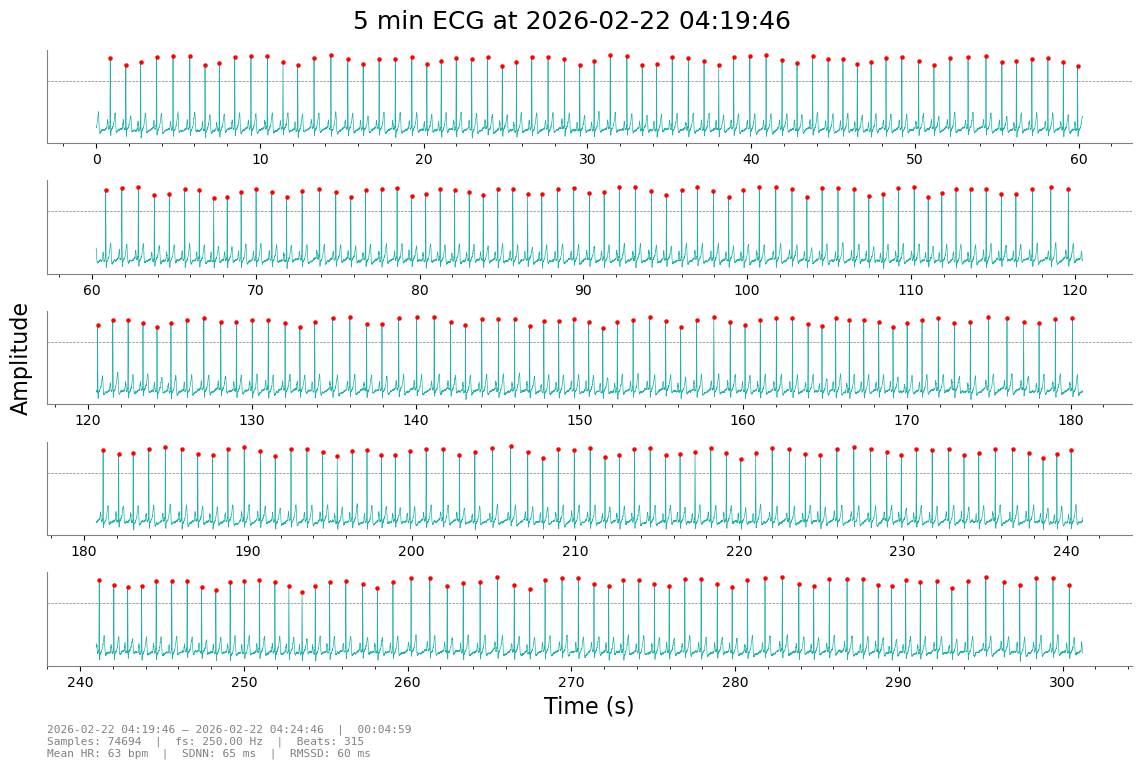

In [5]:
sub_df, t0, t1 = random_time_slice(ecg, s=300)
beats = BeatCalc(sub_df)
begin_idx = sub_df.index[0]
begin_time = sub_df['time'].values[0]
begin_dtime = get_dtime_nospace(begin_time)

idxs = [int(begin_idx+i*60*beats.fs) for i in range(6)]
idx_ranges = [range(idxs[i], idxs[i+1]) for i in range(5)]

print(beats.ecg_info())

fig, axes = plt.subplots(5, 1, figsize=(14, 8), sharey=True)
fig.subplots_adjust(hspace=0.4)

for i in range(5):
    ax = axes[i]
    idx_range = idx_ranges[i]
    df_i = ecg.loc[idx_range].copy()
    df_i['time'] -= begin_time
    beats_i = BeatCalc(df_i)
    beat_idxs = beats_i.peaks

    ax.plot(
        df_i['time'], df_i['ecg'], 
        linewidth=0.5, zorder=-1,
        color='lightseagreen'
        )
    ax.scatter(
        df_i.iloc[beat_idxs]['time'], 
        df_i.iloc[beat_idxs]['ecg'], 
        color='red', zorder=1, s=5
    )
    ax.axhline(
        450, color='gray', 
        linewidth=0.5, 
        linestyle='--'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('gray')
    ax.spines['left'].set_color('gray')
    
    #ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))
    #ax.set_xlim(min(df_i['time']), max(df_i['time']))
    ax.yaxis.set_major_locator(ticker.NullLocator())



axes[-1].set_xlabel('Time (s)', fontsize=16)
axes[2].set_ylabel('Amplitude', fontsize=16, labelpad=10)
axes[-1].text(
    0, -1,                 # 左下角
    beats.ecg_info(),
    transform=ax.transAxes,     # 用轴坐标
    fontsize=8,                 # 小字
    verticalalignment='bottom',
    horizontalalignment='left',
    color='gray',
    family='monospace',         # 等宽字体更监护仪风
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.7,
        edgecolor='none'
    )
)

fig.suptitle(
    f"5 min ECG at {beats.ecg_info()[:19]}", 
    fontsize=18, y=0.93
    )

plt.savefig(
    '5_min_ecg_%s_hr_%.0f.jpg'%(begin_dtime, beats.hr), 
    dpi=300, bbox_inches='tight'
    )


## 3. 异常值检测

In [6]:
ecg_beats = BeatCalc(ecg)
print(ecg_beats.ecg_info())

2026-02-21 23:38:42 – 2026-02-22 08:47:37  |  09:08:54
Samples: 8200220  |  fs: 250.00 Hz  |  Beats: 35125
Mean HR: 64 bpm  |  SDNN: 140 ms  |  RMSSD: 105 ms


In [7]:
peaks = ecg_beats.peaks
fs = ecg_beats.fs

# 1) RR（秒）
rr = np.diff(peaks) / fs
t_rr = peaks[1:] / fs          # RR对应的时间点（第二个峰的时间）

rr_s = pd.Series(rr, index=t_rr, dtype=float)

# 2) 物理边界剔除
rr_s[(rr_s < 0.50) | (rr_s > 2.00)] = np.nan

# 3) 跳变剔除（相邻差分）
drr = rr_s.diff().abs()
rr_s[drr > 0.20] = np.nan

# 4) 可选：再来一个相对跳变（更稳）
rel = (rr_s.diff().abs() / rr_s.shift(1)).abs()
rr_s[rel > 0.25] = np.nan


# 5) 插值（让曲线连续）
rr_clean = rr_s.interpolate(limit=3).dropna()

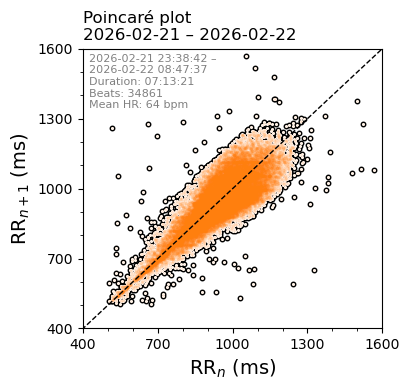

In [34]:
x = rr_clean.to_numpy() * 1000
diag = np.linspace(200, 1600)

fig = plt.figure(figsize=(4.2,4))
ax = plt.gca()

ax.scatter(x[:-1], x[1:], s=5, color="0.0", lw=2)
ax.scatter(x[:-1], x[1:], s=5, color="1.0", lw=0)
ax.scatter(x[:-1], x[1:], s=5, color="C1", lw=0, alpha=0.1)
ax.plot(diag, diag, color='k', linewidth=1, linestyle='--')

ax.set_xlabel("RR$_n$ (ms)", fontsize=14)
ax.set_ylabel("RR$_{n+1}$ (ms)", fontsize=14)

begin_date, begin_time = get_dtime(ecg_beats.begin_time).split()
end_date, end_time = get_dtime(ecg_beats.end_time).split()

if begin_date == end_date:
    ax.set_title(f"Poincaré plot at {begin_date}")
    ax.text(425, 1400,
        f"{begin_time} – {end_time}\nDuration: 07:13:21\n"
        f"{len(rr_clean)} beats\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )
else:
    ax.set_title(f"Poincaré plot\n{begin_date} – {end_date}", loc="left")
    ax.text(425, 1345,
        f"{begin_date} {begin_time} –\n{end_date} {end_time}\nDuration: 07:13:21\n"
        f"Beats: {len(rr_clean)}\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )

ax.set_xlim(400, 1600)
ax.set_ylim(400, 1600)
ax.xaxis.set_major_locator(ticker.LinearLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.LinearLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(100))

plt.tight_layout()

begin_time = ecg['time'].values[0]
begin_dtime = get_dtime_nospace(begin_time)
plt.savefig('poincare_%s.jpg'%begin_dtime, dpi=500)


## 4. HRV 指标, SD1/SD2 ellipse

In [ ]:

def hrv_metrics_from_rr(rr_s, *, unit="s"):
    """
    Compute basic HRV metrics from RR intervals.

    Parameters
    ----------
    rr_s : array-like or pd.Series
        RR intervals. Default expected unit is seconds.
        Can contain NaN; will be dropped.
    unit : {"s","ms"}
        Unit of rr_s.

    Returns
    -------
    metrics : dict
        Keys include:
        - n_beats (int)
        - mean_rr_ms, median_rr_ms
        - mean_hr_bpm
        - sdnn_ms
        - rmssd_ms
        - pnn50_pct
        - poincare_sd1_ms, poincare_sd2_ms, sd1_sd2
    """
    rr = np.asarray(rr_s, dtype=float)
    rr = rr[~np.isnan(rr)]
    if rr.size < 3:
        raise ValueError("Need at least 3 RR intervals after NaN removal.")

    # Convert to seconds internally
    if unit == "ms":
        rr_sec = rr / 1000.0
    elif unit == "s":
        rr_sec = rr
    else:
        raise ValueError("unit must be 's' or 'ms'")

    rr_ms = rr_sec * 1000.0
    drr_ms = np.diff(rr_ms)

    mean_rr_ms = float(np.mean(rr_ms))
    median_rr_ms = float(np.median(rr_ms))
    mean_hr_bpm = float(60.0 / np.mean(rr_sec))

    # Time-domain
    sdnn_ms = float(np.std(rr_ms, ddof=1))
    rmssd_ms = float(np.sqrt(np.mean(drr_ms**2)))

    # pNN50
    pnn50_pct = float(100.0 * np.mean(np.abs(drr_ms) > 50.0))

    # Poincaré (standard definitions)
    # SD1 relates to short-term variability; SD2 to long-term.
    sd1_ms = float(np.sqrt(0.5) * np.std(drr_ms, ddof=1))
    sd2_ms = float(np.sqrt(2.0 * sdnn_ms**2 - 0.5 * np.std(drr_ms, ddof=1)**2))
    sd1_sd2 = float(sd1_ms / sd2_ms) if sd2_ms > 0 else np.nan

    return {
        "n_beats": int(rr_ms.size),
        "mean_rr_ms": mean_rr_ms,
        "median_rr_ms": median_rr_ms,
        "mean_hr_bpm": mean_hr_bpm,
        "sdnn_ms": sdnn_ms,
        "rmssd_ms": rmssd_ms,
        "pnn50_pct": pnn50_pct,
        "poincare_sd1_ms": sd1_ms,
        "poincare_sd2_ms": sd2_ms,
        "sd1_sd2": sd1_sd2,
    }


def add_poincare_ellipse(ax, mean_rr_ms, sd1_ms, sd2_ms, n_std=2.0, **kwargs):
    """
    Draw Poincaré ellipse centered at (mean_rr_ms, mean_rr_ms),
    with axes aligned to the identity line, using SD1/SD2.
    n_std controls ellipse size (e.g., 1, 2, 3).
    """
    # Parametric ellipse in SD2-SD1 coordinate frame
    theta = np.linspace(0, 2*np.pi, 400)
    a = n_std * sd2_ms  # along identity line
    b = n_std * sd1_ms  # perpendicular
    u = a * np.cos(theta)
    v = b * np.sin(theta)

    # Rotate back to (RRn, RRn+1) coordinates:
    # identity/perpendicular basis is rotated by 45 degrees
    x_ell = mean_rr_ms + (u - v) / np.sqrt(2)
    y_ell = mean_rr_ms + (u + v) / np.sqrt(2)

    ax.plot(x_ell, y_ell, **kwargs)


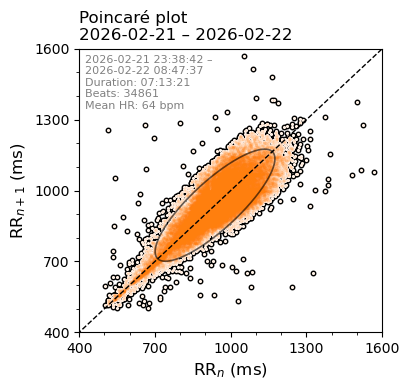

In [33]:
metrics = hrv_metrics_from_rr(rr_clean, unit="s")
mean_rr_ms = np.mean(x)  # 你这里 x 已经是 rr_clean*1000 的 ms
sd1 = metrics["poincare_sd1_ms"]
sd2 = metrics["poincare_sd2_ms"]

x = rr_clean.to_numpy() * 1000
diag = np.linspace(200, 1600)

fig = plt.figure(figsize=(4.2,4))
ax = plt.gca()

ax.scatter(x[:-1], x[1:], s=5, color="0.0", lw=2)
ax.scatter(x[:-1], x[1:], s=5, color="1.0", lw=0)
ax.scatter(x[:-1], x[1:], s=5, color="C1", lw=0, alpha=0.1)
ax.plot(diag, diag, color='k', linewidth=1, linestyle='--')

ax.set_xlabel("RR$_n$ (ms)", fontsize=12)
ax.set_ylabel("RR$_{n+1}$ (ms)", fontsize=12)

begin_date, begin_time = get_dtime(ecg_beats.begin_time).split()
end_date, end_time = get_dtime(ecg_beats.end_time).split()

if begin_date == end_date:
    ax.set_title(f"Poincaré plot at {begin_date}")
    ax.text(425, 1400,
        f"{begin_time} – {end_time}\nDuration: 07:13:21\n"
        f"{len(rr_clean)} beats\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )
else:
    ax.set_title(f"Poincaré plot\n{begin_date} – {end_date}", loc="left")
    ax.text(425, 1345,
        f"{begin_date} {begin_time} –\n{end_date} {end_time}\nDuration: 07:13:21\n"
        f"Beats: {len(rr_clean)}\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )

ax.set_xlim(400, 1600)
ax.set_ylim(400, 1600)
ax.xaxis.set_major_locator(ticker.LinearLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.LinearLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(100))



add_poincare_ellipse(
    ax, mean_rr_ms, sd1, sd2,
    n_std=2.0,
    color="k", linewidth=1.2, alpha=0.6
)

plt.tight_layout()

begin_time = ecg['time'].values[0]
begin_dtime = get_dtime_nospace(begin_time)
plt.savefig('ellipse_poincare_%s.jpg'%begin_dtime, dpi=500)




## 5. 最低心率

In [ ]:
def get_time_slice(df, s, begin_idx, time_col='time'):
    t = df[time_col].to_numpy()
    t_min = t.min()
    t_max = t.max()

    if (t_max - t_min) < s:
        raise ValueError("数据总时长不足 s 秒")
    
    beats = BeatCalc(df)
    end_idx = int(begin_idx+ s*beats.fs)

    if end_idx > df.index.max():
        raise ValueError("样本不足 s 秒")
    slice_df = df.loc[begin_idx: end_idx]
    return slice_df, t_min, t_max

(                 time  ecg  lead
 1090739  1.771525e+09  520     0
 1090740  1.771525e+09  513     0
 1090741  1.771525e+09  471     0
 1090742  1.771525e+09  423     0
 1090743  1.771525e+09  390     0
 ...               ...  ...   ...
 1165735  1.771526e+09  343     0
 1165736  1.771526e+09  341     0
 1165737  1.771526e+09  336     0
 1165738  1.771526e+09  333     0
 1165739  1.771526e+09  332     0
 
 [75001 rows x 3 columns],
 np.float64(1771520865.5739346),
 np.float64(1771546867.0473504))

In [213]:
rr_idxs = np.where(rr_s > 1.2)[0]
rr_int = [[idx, rr_s.values[idx]] for idx in rr_idxs]
peak_idxs = ecg_beats.peaks[rr_idxs]
#test_idx = np.random.choice(peak_idxs)

print(sorted(rr_int,key=lambda x:x[0], reverse=True))

test_idx = 15623
sub_df, t0, t1 = get_time_slice(ecg, 300, test_idx)

[[np.int64(26989), np.float64(1.2039844989776611)], [np.int64(26988), np.float64(1.2159843444824219)], [np.int64(26932), np.float64(1.2039844989776611)], [np.int64(26869), np.float64(1.211984395980835)], [np.int64(26868), np.float64(1.207984447479248)], [np.int64(26813), np.float64(1.2039844989776611)], [np.int64(26812), np.float64(1.2319841384887695)], [np.int64(26796), np.float64(1.211984395980835)], [np.int64(26789), np.float64(1.2039844989776611)], [np.int64(26759), np.float64(1.207984447479248)], [np.int64(26755), np.float64(1.2039844989776611)], [np.int64(26623), np.float64(1.2039844989776611)], [np.int64(26478), np.float64(1.211984395980835)], [np.int64(26477), np.float64(1.2439839839935303)], [np.int64(26475), np.float64(1.2159843444824219)], [np.int64(26399), np.float64(1.2319841384887695)], [np.int64(26320), np.float64(1.2239842414855957)], [np.int64(26297), np.float64(1.2039844989776611)], [np.int64(26276), np.float64(1.211984395980835)], [np.int64(26125), np.float64(1.20798